# 5분 실습: loss가 내려가는 것을 직접 본다

《내가 다시 AI를 처음 공부한다면》(권구민) 2장의 실습 노트북입니다.

하는 법은 하나뿐입니다. 위에서부터 셀마다 실행 버튼(▶)을 누르세요.
지금은 코드가 안 읽혀도 괜찮습니다. 이 노트북의 목적은 코드 이해가 아니라, 이 책이 앞으로 수백 번 말할 장면 **loss 곡선이 내려가는 순간** 을 눈으로 미리 봐두는 것입니다.

In [ ]:
# [1] 준비: 도구와 데이터 (처음 한 번은 1분쯤 걸릴 수 있습니다)
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from IPython.display import clear_output

torch.manual_seed(42)   # 난수 고정. 누가 돌려도 같은 결과가 나오게 (5장에서 이 '주사위' 이야기를 만납니다)

train = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
loader = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)
print(f"손글씨 숫자 이미지 {len(train):,}장 준비 완료")

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 600kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]

손글씨 숫자 이미지 60,000장 준비 완료


## 모델

작은 신경망 하나를 만듭니다. 28×28 손글씨 이미지(숫자 784개)를 받아서, 0~9 중 무엇인지 점수를 매기는 기계입니다.

In [ ]:
# [2] 모델: 숫자 784개를 받아 0~9의 점수 10개를 내놓는 작은 신경망
def make_model():
    return nn.Sequential(
        nn.Flatten(),           # 이미지를 숫자 784개짜리 한 줄로 편다
        nn.Linear(784, 128),    # 가중치 행렬. 학습이 고쳐나가는 값들이 여기 있다
        nn.ReLU(),              # 구부리기. 직선만으로는 안 되는 이유는 3장에서
        nn.Linear(128, 10),     # 0~9 각각의 점수
    )

model = make_model()
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


## 학습

아래 반복문이 이 책 5장의 **네 박자**입니다: forward(예측) -> loss(채점) -> backward(책임 계산) -> update(고치기). 미니 GPT든 챗GPT든, 학습이라는 것의 뼈대는 전부 이 네 줄입니다.

실행하면 loss 곡선이 실시간으로 그려집니다. 약 1~2분 걸립니다.

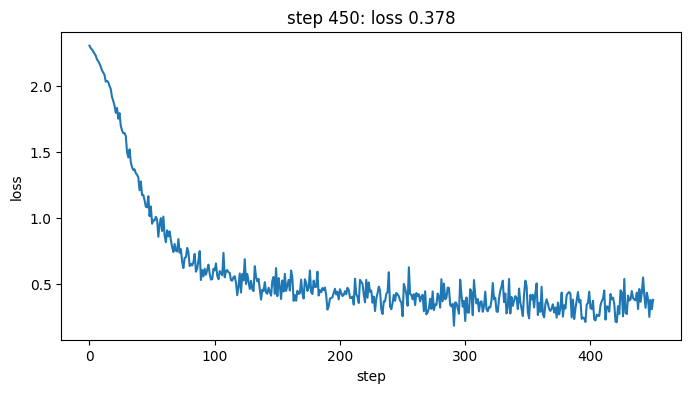

In [ ]:
# [3] 학습: 네 박자를 450번 반복하며 loss 곡선을 그린다
model = make_model()
opt = torch.optim.SGD(model.parameters(), lr=0.1)   # lr = 한 걸음의 보폭
loss_fn = nn.CrossEntropyLoss()

losses = []
for step, (x, y) in enumerate(loader):
    pred = model(x)             # 1. forward  : 예측하고
    loss = loss_fn(pred, y)     # 2. loss     : 얼마나 틀렸는지 재고
    opt.zero_grad()
    loss.backward()             # 3. backward : 각 가중치의 책임을 계산하고
    opt.step()                  # 4. update   : 그만큼 고친다
    losses.append(loss.item())

    if step % 25 == 0:          # 25걸음마다 곡선을 다시 그린다
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        plt.plot(losses)
        plt.xlabel("step"); plt.ylabel("loss")
        plt.title(f"step {step}: loss {loss.item():.3f}")
        plt.show()
    if step >= 450:
        break

### 방금 본 것

- **첫 loss는 왜 2.3 근처일까?** 아무것도 모르는 모델은 10개의 숫자에 확률을 고르게 걸 수밖에 없고, 그때의 loss가 정확히 -log(1/10) ≈ 2.303입니다. 우연이 아니라 계산되는 값입니다. 이 계산은 3장에서 배웁니다.
- **처음엔 가파르게, 나중엔 완만하게** 내려갑니다. 곡선의 이 모양이 무엇을 말하는지는 5장 "loss 곡선의 세 표정"에서 다룹니다.
- 곡선이 잘게 떨리는 것은 고장이 아닙니다. 128장씩 뽑아 채점하기 때문에 생기는 자연스러운 흔들림입니다.

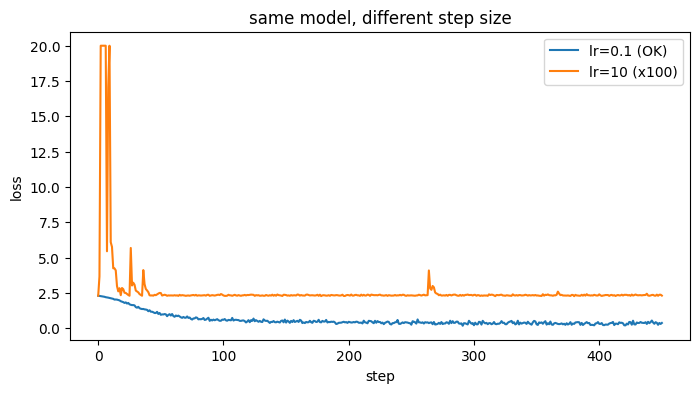

In [ ]:
# [4] 이번엔 일부러 망가뜨린다: 보폭(lr)을 100배로 키우면?
model2 = make_model()
opt2 = torch.optim.SGD(model2.parameters(), lr=10.0)   # 아까는 0.1이었다

bad = []
for step, (x, y) in enumerate(loader):
    loss = loss_fn(model2(x), y)
    opt2.zero_grad(); loss.backward(); opt2.step()
    v = loss.item()
    bad.append(20.0 if (v != v or v > 20) else v)   # 그래프 밖으로 뚫고 나가면 20에서 자른다
    if step >= 450:
        break

plt.figure(figsize=(8, 4))
plt.plot(losses, label="lr=0.1 (OK)")
plt.plot(bad, label="lr=10 (x100)")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend()
plt.title("same model, different step size")
plt.show()

### 무슨 일이 벌어졌나

주황 곡선은 치솟았다가, 이내 **2.3 근처에 눌러앉습니다.** 2.3은 아까 본 "아무것도 모르는 상태"의 loss입니다. 보폭이 너무 크면 모델은 배우기는커녕 부서져서, 찍기 수준으로 되돌아간 채 영영 내려오지 못합니다. 같은 모델, 같은 데이터인데 보폭 하나로 학습과 붕괴가 갈립니다. 왜 그런지는 3장의 "안개 낀 산" 그림 하나로 이해하게 됩니다.

---

여기까지입니다. 오늘 본 두 곡선을 기억해두세요. 3장에서 이 곡선을 움직이는 수학을 배우고, 5장에서 이 루프의 구조를 뜯고, 6장에서는 진짜 GPT를 학습시키며 같은 곡선을 다시 읽게 됩니다. 그때마다 이 화면이 기준점이 될 것입니다.

<sub>데이터: MNIST 손글씨 숫자 데이터셋 (Y. LeCun, C. Cortes, C. Burges) · CC BY-SA 3.0. 이 노트북은 데이터를 포함하지 않으며 실행 시 공식 배포처에서 내려받습니다.</sub>